# COMPAS Model Stress Testing and Security Audit

This notebook implements a COMPAS model security audit pipeline. It evaluates three adversarial risk areas: PGD-style evasion, label-flip poisoning with fairness monitoring, and shadow-model membership inference. The interpretation focuses on audit evidence: what changes under attack, what standard metrics miss, and what governance action the result supports.

## 0. Setup, Data, And Clean Baseline

The notebook uses the ProPublica COMPAS dataset and a consistent preprocessing pipeline for security testing. The target is `two_year_recid`, and the protected-group audit focuses on false positive rates for African-American and Caucasian defendants. AIR is computed as `FPR_African-American / FPR_Caucasian`, so values outside `[0.80, 1.25]` are treated as a practical disparity flag.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
THR = 0.50
AA = "African-American"
CA = "Caucasian"
EPSILONS = [0.25, 0.50, 1.00, 2.00]
POISON_RATES = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
C_VALUES = [0.01, 0.10, 1.00, 10.00]

In [2]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df = pd.read_csv(url)

# COMPAS / ProPublica inclusion filters.
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]

features_raw = [
    "age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count",
    "c_charge_degree", "sex",
]
target = "two_year_recid"

df_m = df[features_raw + [target, "race"]].dropna().copy()
df_m = pd.get_dummies(df_m, columns=["c_charge_degree", "sex"], drop_first=True)

X = df_m.drop(columns=[target, "race"]).astype(float)
y = df_m[target].astype(int).to_numpy()
race = df_m["race"].astype(str).to_numpy()

X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
Xs_tr = scaler.fit_transform(X_tr)
Xs_te = scaler.transform(X_te)
feature_names = list(X.columns)

print(f"Filtered dataset rows: {len(df_m):,}")
print(f"Train rows: {len(X_tr):,}; Test rows: {len(X_te):,}")
print(f"Features after dummy encoding: {feature_names}")
print(f"Recidivism rate: {y.mean():.3f}")

Filtered dataset rows: 6,172
Train rows: 4,320; Test rows: 1,852
Features after dummy encoding: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree_M', 'sex_Male']
Recidivism rate: 0.455


In [3]:
def make_lr(C=1.0):
    return LogisticRegression(max_iter=1000, C=C, solver="lbfgs", random_state=RANDOM_STATE)


def make_gbt(seed=RANDOM_STATE):
    return GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=seed)


def fpr_by_group(y_true, y_pred_binary, groups):
    mask = y_true == 0
    return (
        pd.DataFrame({"pred": y_pred_binary[mask], "group": groups[mask]})
        .groupby("group")["pred"]
        .mean()
    )


def air_ratio(fpr_aa, fpr_ca):
    return fpr_aa / fpr_ca if pd.notna(fpr_ca) and fpr_ca > 0 else np.nan


def metrics_for_model(model, X_eval, y_true, groups):
    prob = model.predict_proba(X_eval)[:, 1]
    pred = (prob >= THR).astype(int)
    fpr = fpr_by_group(y_true, pred, groups)
    fpr_aa = fpr.get(AA, np.nan)
    fpr_ca = fpr.get(CA, np.nan)
    return {
        "auc": roc_auc_score(y_true, prob),
        "FPR_AA": fpr_aa,
        "FPR_CA": fpr_ca,
        "AIR_AA_over_CA": air_ratio(fpr_aa, fpr_ca),
        "mean_score": prob.mean(),
        "predicted_positive_rate": pred.mean(),
    }

lr = make_lr().fit(Xs_tr, y_tr)
gbt = make_gbt().fit(Xs_tr, y_tr)
models = {"LR": lr, "GBT": gbt}

baseline_rows = []
for name, model in models.items():
    train_auc = roc_auc_score(y_tr, model.predict_proba(Xs_tr)[:, 1])
    test_metrics = metrics_for_model(model, Xs_te, y_te, r_te)
    baseline_rows.append({
        "model": name,
        "train_auc": train_auc,
        "test_auc": test_metrics["auc"],
        "generalization_gap": train_auc - test_metrics["auc"],
        "FPR_AA": test_metrics["FPR_AA"],
        "FPR_CA": test_metrics["FPR_CA"],
        "AIR_AA_over_CA": test_metrics["AIR_AA_over_CA"],
        "predicted_positive_rate": test_metrics["predicted_positive_rate"],
    })

baseline_table = pd.DataFrame(baseline_rows)
display(baseline_table.round(4))

,model,train_auc,test_auc,generalization_gap,FPR_AA,FPR_CA,AIR_AA_over_CA,predicted_positive_rate
0,LR,0.7269,0.7345,-0.0077,0.2809,0.1432,1.9614,0.3569
1,GBT,0.7981,0.7179,0.0802,0.3169,0.1778,1.7823,0.3780


The clean baseline already shows disparity: African-American defendants have higher false positive rates than Caucasian defendants for both models. The GBT has a higher training AUC but lower test AUC than LR, which creates a larger generalization gap. This baseline matters because the attack results should be interpreted relative to both predictive utility and subgroup harm.

## 1. Part A: PGD Evasion Audit

This section tests deployment-time evasion. For LR, the attack uses the sign of the fitted coefficients to increase predicted recidivism scores. For GBT, which does not expose analytic gradients, the notebook uses a finite-difference score-gradient approximation. The GBT result should therefore be interpreted as a practical score-based PGD-style audit for a non-differentiable model.

In [4]:
def pgd_lr(model, X0, epsilon, alpha=None, n_iter=40):
    if alpha is None:
        alpha = max(epsilon / 10, 0.02)
    X_adv = X0.copy()
    step_sign = np.sign(model.coef_[0])[None, :]
    for _ in range(n_iter):
        X_adv = X_adv + alpha * step_sign
        X_adv = np.clip(X_adv, X0 - epsilon, X0 + epsilon)
    return X_adv


def pgd_score_finite_diff(model, X0, epsilon, alpha=None, n_iter=15, fd_step=0.10):
    if alpha is None:
        alpha = max(epsilon / 8, 0.03)
    X_adv = X0.copy()
    n_features = X0.shape[1]
    for _ in range(n_iter):
        grad = np.zeros_like(X_adv)
        for j in range(n_features):
            x_plus = X_adv.copy()
            x_minus = X_adv.copy()
            x_plus[:, j] += fd_step
            x_minus[:, j] -= fd_step
            grad[:, j] = (
                model.predict_proba(x_plus)[:, 1] - model.predict_proba(x_minus)[:, 1]
            ) / (2 * fd_step)
        X_adv = X_adv + alpha * np.sign(grad)
        X_adv = np.clip(X_adv, X0 - epsilon, X0 + epsilon)
    return X_adv

pgd_rows = []
for eps in EPSILONS:
    X_adv_lr = pgd_lr(lr, Xs_te, eps)
    X_adv_gbt = pgd_score_finite_diff(gbt, Xs_te, eps)
    for name, model, X_adv in [("LR", lr, X_adv_lr), ("GBT", gbt, X_adv_gbt)]:
        attacked = metrics_for_model(model, X_adv, y_te, r_te)
        pgd_rows.append({
            "model": name,
            "epsilon": eps,
            "FPR_AA": attacked["FPR_AA"],
            "FPR_CA": attacked["FPR_CA"],
            "AIR_AA_over_CA": attacked["AIR_AA_over_CA"],
            "test_auc_under_attack": attacked["auc"],
            "predicted_positive_rate": attacked["predicted_positive_rate"],
        })

pgd_table = pd.DataFrame(pgd_rows)
display(pgd_table.round(4))

crossing_rows = []
for name, group in pgd_table.groupby("model"):
    below = group[group["AIR_AA_over_CA"] < 0.80]
    outside = group[(group["AIR_AA_over_CA"] < 0.80) | (group["AIR_AA_over_CA"] > 1.25)]
    crossing_rows.append({
        "model": name,
        "first_epsilon_AIR_below_0_80": np.nan if below.empty else below.iloc[0]["epsilon"],
        "first_epsilon_outside_0_80_to_1_25": np.nan if outside.empty else outside.iloc[0]["epsilon"],
    })

pgd_crossing_table = pd.DataFrame(crossing_rows)
display(pgd_crossing_table)

,model,epsilon,FPR_AA,FPR_CA,AIR_AA_over_CA,test_auc_under_attack,predicted_positive_rate
0,LR,0.25,0.5685,0.3704,1.5351,0.7345,0.5999
1,GBT,0.25,0.4517,0.2741,1.6480,0.7014,0.5011
2,LR,0.50,0.7910,0.5605,1.4113,0.7345,0.7748
3,GBT,0.50,0.4607,0.2889,1.5946,0.6918,0.5157
4,LR,1.00,0.9775,0.8840,1.1059,0.7345,0.9563
5,GBT,1.00,0.4831,0.3062,1.5780,0.6952,0.5378
6,LR,2.00,1.0000,1.0000,1.0000,0.7345,1.0000
7,GBT,2.00,0.4022,0.2543,1.5817,0.6866,0.4741


,model,first_epsilon_AIR_below_0_80,first_epsilon_outside_0_80_to_1_25
0,GBT,NaN,0.25
1,LR,NaN,0.25


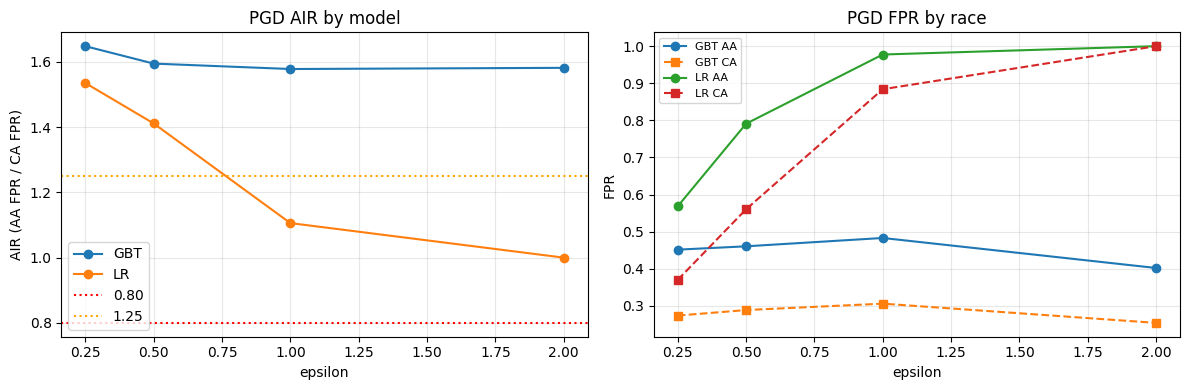

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, group in pgd_table.groupby("model"):
    axes[0].plot(group["epsilon"], group["AIR_AA_over_CA"], "o-", label=name)
axes[0].axhline(0.80, color="red", linestyle=":", label="0.80")
axes[0].axhline(1.25, color="orange", linestyle=":", label="1.25")
axes[0].set_xlabel("epsilon")
axes[0].set_ylabel("AIR (AA FPR / CA FPR)")
axes[0].set_title("PGD AIR by model")
axes[0].legend()
axes[0].grid(alpha=0.3)

for name, group in pgd_table.groupby("model"):
    axes[1].plot(group["epsilon"], group["FPR_AA"], "o-", label=f"{name} AA")
    axes[1].plot(group["epsilon"], group["FPR_CA"], "s--", label=f"{name} CA")
axes[1].set_xlabel("epsilon")
axes[1].set_ylabel("FPR")
axes[1].set_title("PGD FPR by race")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The two models are not equally vulnerable. LR becomes almost fully positive at high epsilon, so both racial groups approach FPR = 1.0 by epsilon 2.0; this makes the AIR ratio approach 1.0 even though the model is operationally unusable. GBT has lower FPR movement than LR under this score-based attack, but its AIR remains outside the `[0.80, 1.25]` range at every tested epsilon. AIR never falls below 0.80 for either model; the disparity issue is instead that AIR remains above the upper parity bound. For high-stakes use, model selection should not rely only on AUC because an attack can change decision rates and subgroup harm without a comparable warning from ranking performance.

## 2. Part B: Poisoning Loop With Fairness Monitoring

This section simulates training-time label-flip poisoning. The attack flips a fraction of positive recidivism labels to zero for one target race, then retrains the LR model. Two variants are compared: African-American-targeted poisoning and Caucasian-targeted poisoning.

In [6]:
def poison_label_flip(y_train, race_train, poison_rate, target_race, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_poisoned = y_train.copy()
    candidates = np.where((race_train == target_race) & (y_train == 1))[0]
    n_flip = int(len(candidates) * poison_rate)
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0
    return y_poisoned, n_flip

base_lr_auc = baseline_table.loc[baseline_table["model"] == "LR", "test_auc"].iloc[0]

poison_rows = []
for target_race in [AA, CA]:
    for rate in POISON_RATES:
        y_poisoned, n_flipped = poison_label_flip(y_tr, r_tr, rate, target_race, seed=RANDOM_STATE)
        poisoned_lr = make_lr().fit(Xs_tr, y_poisoned)
        metrics = metrics_for_model(poisoned_lr, Xs_te, y_te, r_te)
        outside = (metrics["AIR_AA_over_CA"] < 0.80) or (metrics["AIR_AA_over_CA"] > 1.25)
        poison_rows.append({
            "target_race": target_race,
            "poison_rate": rate,
            "n_flipped": n_flipped,
            "AUC": metrics["auc"],
            "AUC_drop": base_lr_auc - metrics["auc"],
            "FPR_AA": metrics["FPR_AA"],
            "FPR_CA": metrics["FPR_CA"],
            "AIR_AA_over_CA": metrics["AIR_AA_over_CA"],
            "outside_AIR_range": outside,
            "attack_stealth_zone": (rate > 0) and (base_lr_auc - metrics["auc"] <= 0.02) and outside,
        })

poison_table = pd.DataFrame(poison_rows)
display(poison_table.round(4))

stealth_table = poison_table[poison_table["attack_stealth_zone"]].copy()
display(stealth_table[["target_race", "poison_rate", "n_flipped", "AUC_drop", "AIR_AA_over_CA"]].round(4))

,target_race,poison_rate,n_flipped,AUC,AUC_drop,FPR_AA,FPR_CA,AIR_AA_over_CA,outside_AIR_range,attack_stealth_zone
0,African-American,0.00,0,0.7345,0.0000,0.2809,0.1432,1.9614,True,False
1,African-American,0.02,23,0.7342,0.0004,0.2697,0.1333,2.0225,True,True
2,African-American,0.05,57,0.7350,-0.0005,0.2315,0.1235,1.8748,True,True
3,African-American,0.08,92,0.7338,0.0008,0.2157,0.1111,1.9416,True,True
4,African-American,0.10,115,0.7330,0.0016,0.2000,0.1037,1.9286,True,True
5,African-American,0.15,172,0.7327,0.0018,0.1528,0.0716,2.1341,True,True
6,African-American,0.20,230,0.7285,0.0060,0.1281,0.0543,2.3580,True,True
7,African-American,0.25,287,0.7290,0.0055,0.1124,0.0469,2.3950,True,True
8,African-American,0.30,345,0.7307,0.0039,0.0989,0.0346,2.8604,True,True
9,Caucasian,0.00,0,0.7345,0.0000,0.2809,0.1432,1.9614,True,False


,target_race,poison_rate,n_flipped,AUC_drop,AIR_AA_over_CA
1,African-American,0.02,23,0.0004,2.0225
2,African-American,0.05,57,-0.0005,1.8748
3,African-American,0.08,92,0.0008,1.9416
4,African-American,0.10,115,0.0016,1.9286
5,African-American,0.15,172,0.0018,2.1341
6,African-American,0.20,230,0.0060,2.3580
7,African-American,0.25,287,0.0055,2.3950
8,African-American,0.30,345,0.0039,2.8604
10,Caucasian,0.02,11,-0.0002,1.9827
11,Caucasian,0.05,29,0.0011,2.0606


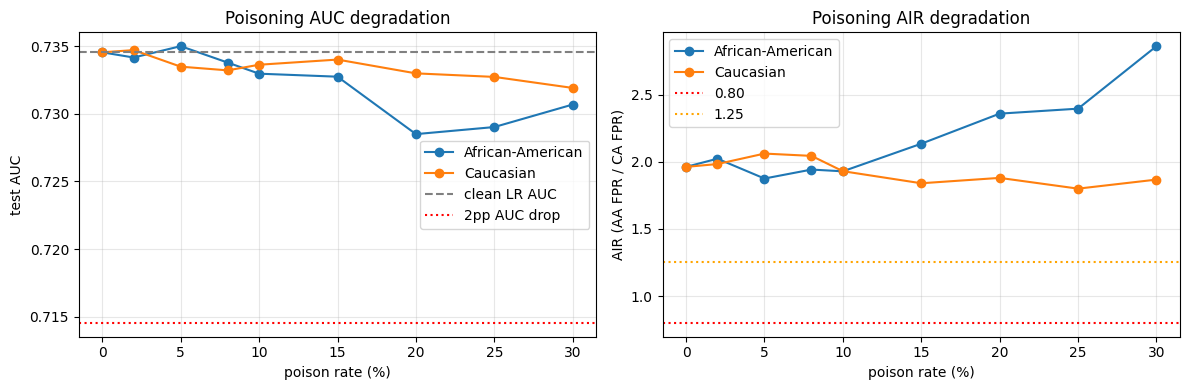

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for target_race, group in poison_table.groupby("target_race"):
    axes[0].plot(group["poison_rate"] * 100, group["AUC"], "o-", label=target_race)
axes[0].axhline(base_lr_auc, color="gray", linestyle="--", label="clean LR AUC")
axes[0].axhline(base_lr_auc - 0.02, color="red", linestyle=":", label="2pp AUC drop")
axes[0].set_xlabel("poison rate (%)")
axes[0].set_ylabel("test AUC")
axes[0].set_title("Poisoning AUC degradation")
axes[0].legend()
axes[0].grid(alpha=0.3)

for target_race, group in poison_table.groupby("target_race"):
    axes[1].plot(group["poison_rate"] * 100, group["AIR_AA_over_CA"], "o-", label=target_race)
axes[1].axhline(0.80, color="red", linestyle=":", label="0.80")
axes[1].axhline(1.25, color="orange", linestyle=":", label="1.25")
axes[1].set_xlabel("poison rate (%)")
axes[1].set_ylabel("AIR (AA FPR / CA FPR)")
axes[1].set_title("Poisoning AIR degradation")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The poisoning loop shows a stealth pattern: AUC remains within two percentage points of the clean LR baseline across the tested poison rates, while AIR stays outside the `[0.80, 1.25]` range. Because the clean model is already outside this range, the finding should be interpreted as persistence or worsening of fairness risk under an attack, not as the first creation of disparity. African-American-targeted poisoning increases the AIR ratio at higher poison rates, reaching about 2.86 at 30%, while AUC remains around 0.731. This is a governance concern because aggregate AUC would not trigger review even though subgroup harm remains severe.

## 3. PSI Drift Monitor Check

This section tests whether a PSI monitor with threshold `0.10` on each feature would detect either poisoning attack. Label-flip poisoning changes labels, not feature values, so feature PSI is expected to remain near zero.

,target_race,poison_rate,max_feature_PSI,max_PSI_feature,any_feature_PSI_ge_0_10,label_PSI_for_reference_only
0,African-American,0.00,0.0,age,False,0.0000
1,African-American,0.02,0.0,age,False,0.0001
2,African-American,0.05,0.0,age,False,0.0007
3,African-American,0.08,0.0,age,False,0.0018
4,African-American,0.10,0.0,age,False,0.0029
5,African-American,0.15,0.0,age,False,0.0065
6,African-American,0.20,0.0,age,False,0.0116
7,African-American,0.25,0.0,age,False,0.0181
8,African-American,0.30,0.0,age,False,0.0263
9,Caucasian,0.00,0.0,age,False,0.0000


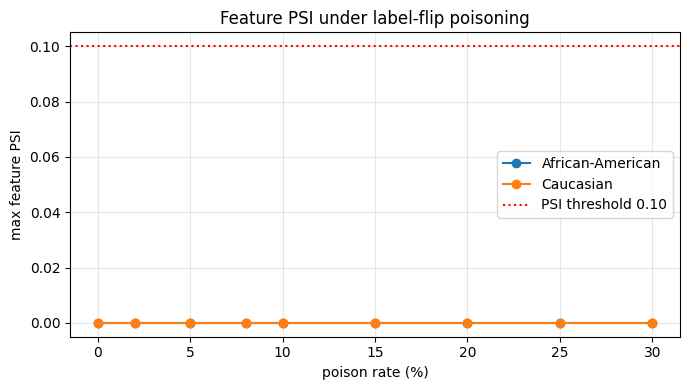

In [8]:
def psi_numeric(a, b, bins=10, eps=1e-6):
    a = pd.to_numeric(pd.Series(a), errors="coerce").dropna().values
    b = pd.to_numeric(pd.Series(b), errors="coerce").dropna().values
    if len(a) == 0 or len(b) == 0:
        return np.nan
    cut_points = np.unique(np.quantile(a, np.linspace(0, 1, bins + 1)))
    if len(cut_points) < 3:
        lo = min(a.min(), b.min())
        hi = max(a.max(), b.max())
        if lo == hi:
            return 0.0
        cut_points = np.linspace(lo, hi, bins + 1)
    cut_points[0] = -np.inf
    cut_points[-1] = np.inf
    a_counts, _ = np.histogram(a, bins=cut_points)
    b_counts, _ = np.histogram(b, bins=cut_points)
    a_pct = np.clip(a_counts / a_counts.sum(), eps, None)
    b_pct = np.clip(b_counts / b_counts.sum(), eps, None)
    return float(np.sum((a_pct - b_pct) * np.log(a_pct / b_pct)))


def max_feature_psi(X_clean, X_candidate):
    values = {col: psi_numeric(X_clean[col], X_candidate[col]) for col in X_clean.columns}
    max_feature = max(values, key=values.get)
    return values[max_feature], max_feature

psi_rows = []
for target_race in [AA, CA]:
    for rate in POISON_RATES:
        y_poisoned, _ = poison_label_flip(y_tr, r_tr, rate, target_race, seed=RANDOM_STATE)
        max_psi, max_feature = max_feature_psi(X_tr, X_tr.copy())
        psi_rows.append({
            "target_race": target_race,
            "poison_rate": rate,
            "max_feature_PSI": max_psi,
            "max_PSI_feature": max_feature,
            "any_feature_PSI_ge_0_10": max_psi >= 0.10,
            "label_PSI_for_reference_only": psi_numeric(y_tr, y_poisoned, bins=2),
        })

psi_table = pd.DataFrame(psi_rows)
display(psi_table.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
for target_race, group in psi_table.groupby("target_race"):
    ax.plot(group["poison_rate"] * 100, group["max_feature_PSI"], "o-", label=target_race)
ax.axhline(0.10, color="red", linestyle=":", label="PSI threshold 0.10")
ax.set_xlabel("poison rate (%)")
ax.set_ylabel("max feature PSI")
ax.set_title("Feature PSI under label-flip poisoning")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

A feature-level PSI monitor would not detect either attack in this setup. The maximum feature PSI is 0.000 at every poison rate because the attack changes labels while leaving the feature matrix unchanged. This is an important monitoring limitation: input drift controls can miss training-label integrity attacks. A stronger monitoring stack would need label audits, data provenance checks, retraining approval controls, and subgroup outcome monitoring.

## 4. Part C: Membership Inference Depth

This section runs a shadow-model membership inference attack for both LR and GBT. The attack uses each model's maximum predicted probability as the confidence signal. A higher MI AUC means the model output reveals more information about whether a record was in the training set.

In [9]:
def shadow_mi_auc(model_factory, target_model, X_train, y_train, X_test, n_shadow=8, seed=RANDOM_STATE):
    train_confidences = []
    test_confidences = []
    splitter = StratifiedShuffleSplit(n_splits=n_shadow, test_size=0.5, random_state=seed)

    for i, (train_idx, test_idx) in enumerate(splitter.split(X_train, y_train)):
        shadow = model_factory(seed + i)
        shadow.fit(X_train[train_idx], y_train[train_idx])
        train_confidences.append(shadow.predict_proba(X_train[train_idx]).max(axis=1))
        test_confidences.append(shadow.predict_proba(X_train[test_idx]).max(axis=1))

    attack_X = np.concatenate(train_confidences + test_confidences).reshape(-1, 1)
    attack_y = np.concatenate(
        [np.ones(len(c)) for c in train_confidences] +
        [np.zeros(len(c)) for c in test_confidences]
    )
    meta_model = DecisionTreeClassifier(max_depth=6, random_state=seed).fit(attack_X, attack_y)

    target_train_conf = target_model.predict_proba(X_train).max(axis=1).reshape(-1, 1)
    target_test_conf = target_model.predict_proba(X_test).max(axis=1).reshape(-1, 1)
    mi_scores = np.concatenate([
        meta_model.predict_proba(target_train_conf)[:, 1],
        meta_model.predict_proba(target_test_conf)[:, 1],
    ])
    mi_labels = np.concatenate([np.ones(X_train.shape[0]), np.zeros(X_test.shape[0])])

    return roc_auc_score(mi_labels, mi_scores), target_train_conf.ravel(), target_test_conf.ravel()


def lr_factory_for_mi(seed=RANDOM_STATE):
    return make_lr()


def gbt_factory_for_mi(seed=RANDOM_STATE):
    return make_gbt(seed)

mi_rows = []
confidence_data = {}
for name, model, factory in [("LR", lr, lr_factory_for_mi), ("GBT", gbt, gbt_factory_for_mi)]:
    mi_auc, train_conf, test_conf = shadow_mi_auc(factory, model, Xs_tr, y_tr, Xs_te, n_shadow=8)
    train_auc = roc_auc_score(y_tr, model.predict_proba(Xs_tr)[:, 1])
    test_auc = roc_auc_score(y_te, model.predict_proba(Xs_te)[:, 1])
    mi_rows.append({
        "model": name,
        "train_auc": train_auc,
        "test_auc": test_auc,
        "generalization_gap": train_auc - test_auc,
        "MI_AUC": mi_auc,
        "mean_train_confidence": train_conf.mean(),
        "mean_test_confidence": test_conf.mean(),
        "confidence_gap": train_conf.mean() - test_conf.mean(),
    })
    confidence_data[name] = (train_conf, test_conf)

mi_table = pd.DataFrame(mi_rows)
display(mi_table.round(4))

,model,train_auc,test_auc,generalization_gap,MI_AUC,mean_train_confidence,mean_test_confidence,confidence_gap
0,LR,0.7269,0.7345,-0.0077,0.5007,0.6576,0.6590,-0.0014
1,GBT,0.7981,0.7179,0.0802,0.5021,0.7019,0.6973,0.0046


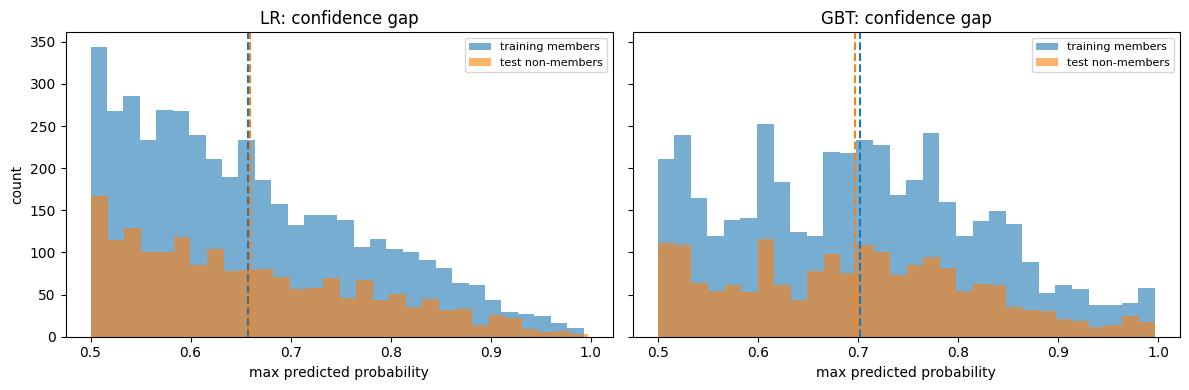

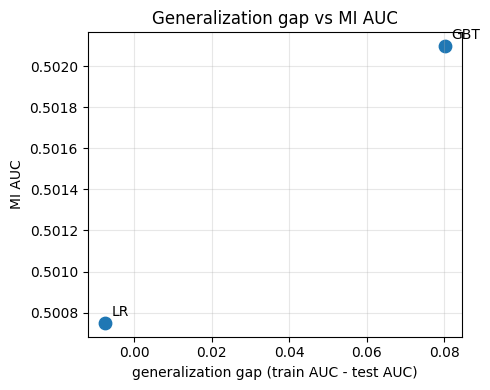

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (name, (train_conf, test_conf)) in zip(axes, confidence_data.items()):
    ax.hist(train_conf, bins=30, alpha=0.60, label="training members")
    ax.hist(test_conf, bins=30, alpha=0.60, label="test non-members")
    ax.axvline(train_conf.mean(), color="C0", linestyle="--")
    ax.axvline(test_conf.mean(), color="C1", linestyle="--")
    ax.set_title(f"{name}: confidence gap")
    ax.set_xlabel("max predicted probability")
    ax.legend(fontsize=8)
axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(mi_table["generalization_gap"], mi_table["MI_AUC"], s=80)
for _, row in mi_table.iterrows():
    ax.annotate(row["model"], (row["generalization_gap"], row["MI_AUC"]), xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("generalization gap (train AUC - test AUC)")
ax.set_ylabel("MI AUC")
ax.set_title("Generalization gap vs MI AUC")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The membership inference attack is close to random guessing for both models: MI AUC is about 0.501 for LR and 0.502 for GBT. GBT has the larger generalization gap, but the MI AUC remains near 0.50, so this two-model comparison does not provide strong evidence that the gap predicts membership leakage here. The confidence histograms show substantial overlap between training members and test non-members. The audit conclusion is not that membership inference is impossible, but that this particular confidence-based shadow attack did not find meaningful leakage.

## 5. L2 Regularization Analysis For LR

This section varies LR regularization strength using `C ∈ {0.01, 0.1, 1.0, 10.0}`. Smaller `C` means stronger L2 regularization. The audit question is whether stronger regularization reduces membership inference risk, and whether that creates a performance or fairness tradeoff.

,C,train_auc,test_auc,generalization_gap,MI_AUC,FPR_AA,FPR_CA,AIR_AA_over_CA
0,0.01,0.7258,0.7321,-0.0064,0.5029,0.2719,0.1383,1.9665
1,0.10,0.7268,0.7342,-0.0074,0.5000,0.2787,0.1432,1.9458
2,1.00,0.7269,0.7345,-0.0077,0.4985,0.2809,0.1432,1.9614
3,10.00,0.7269,0.7346,-0.0077,0.5012,0.2809,0.1432,1.9614


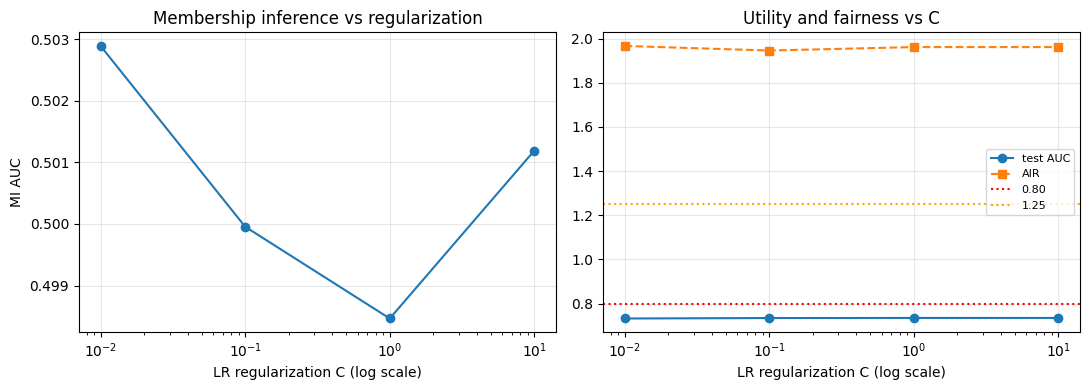

In [11]:
regularization_rows = []
for C in C_VALUES:
    target_lr = make_lr(C=C).fit(Xs_tr, y_tr)

    def lr_factory_with_C(seed=RANDOM_STATE, C=C):
        return make_lr(C=C)

    mi_auc, _, _ = shadow_mi_auc(lr_factory_with_C, target_lr, Xs_tr, y_tr, Xs_te, n_shadow=8, seed=123)
    train_auc = roc_auc_score(y_tr, target_lr.predict_proba(Xs_tr)[:, 1])
    test_auc = roc_auc_score(y_te, target_lr.predict_proba(Xs_te)[:, 1])
    fairness = metrics_for_model(target_lr, Xs_te, y_te, r_te)
    regularization_rows.append({
        "C": C,
        "train_auc": train_auc,
        "test_auc": test_auc,
        "generalization_gap": train_auc - test_auc,
        "MI_AUC": mi_auc,
        "FPR_AA": fairness["FPR_AA"],
        "FPR_CA": fairness["FPR_CA"],
        "AIR_AA_over_CA": fairness["AIR_AA_over_CA"],
    })

regularization_table = pd.DataFrame(regularization_rows)
display(regularization_table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(regularization_table["C"], regularization_table["MI_AUC"], "o-")
axes[0].set_xscale("log")
axes[0].set_xlabel("LR regularization C (log scale)")
axes[0].set_ylabel("MI AUC")
axes[0].set_title("Membership inference vs regularization")
axes[0].grid(alpha=0.3)

axes[1].plot(regularization_table["C"], regularization_table["test_auc"], "o-", label="test AUC")
axes[1].plot(regularization_table["C"], regularization_table["AIR_AA_over_CA"], "s--", label="AIR")
axes[1].axhline(0.80, color="red", linestyle=":", label="0.80")
axes[1].axhline(1.25, color="orange", linestyle=":", label="1.25")
axes[1].set_xscale("log")
axes[1].set_xlabel("LR regularization C (log scale)")
axes[1].set_title("Utility and fairness vs C")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Changing L2 regularization does not materially change membership inference risk in this run; MI AUC remains near 0.50 for all tested values of `C`. Test AUC is also stable, so stronger regularization does not create a large utility penalty here. However, AIR remains well above 1.25 across all `C` values, meaning regularization does not solve the main subgroup-disparity issue. The practical tradeoff is therefore limited for privacy in this experiment, but fairness still requires separate mitigation.

## 6. Reflection: Highest-Risk Finding And Mitigations

This final section summarizes the highest-risk finding and links it to proactive and reactive controls. The mitigation discussion is based on the measured results above, not on a general security checklist.

In [12]:
reflection_table = pd.DataFrame([
    {
        "item": "Highest-risk finding",
        "evidence": "Label-flip poisoning preserved AUC within 2pp while AIR stayed outside [0.80, 1.25]. Feature PSI stayed at 0.000.",
        "audit meaning": "A fairness-damaging training-data attack can evade both aggregate AUC and feature-PSI monitoring.",
    },
    {
        "item": "Proactive mitigation",
        "evidence": "Data provenance, dataset hashing, access separation, and label audit sampling before retraining.",
        "audit meaning": "Targets the attack before model fitting; should prevent or catch label changes that PSI cannot see.",
    },
    {
        "item": "Reactive mitigation",
        "evidence": "Post-training AIR/FPR alerts with rollback review when AIR is outside [0.80, 1.25] or changes sharply.",
        "audit meaning": "Would flag the observed fairness harm even when AUC and feature PSI remain stable.",
    },
])
display(reflection_table)

,item,evidence,audit meaning
0,Highest-risk finding,Label-flip poisoning preserved AUC within 2pp ...,A fairness-damaging training-data attack can e...
1,Proactive mitigation,"Data provenance, dataset hashing, access separ...",Targets the attack before model fitting; shoul...
2,Reactive mitigation,Post-training AIR/FPR alerts with rollback rev...,Would flag the observed fairness harm even whe...


The single highest-risk finding is the poisoning result. In this experiment, the label-flip attack preserved AUC within two percentage points while feature PSI remained 0.000, meaning ordinary performance and input-drift monitoring would not detect the problem. A proactive mitigation is strict data provenance plus label audit sampling before each retraining cycle. A reactive mitigation is subgroup FPR/AIR monitoring with rollback review when AIR is outside `[0.80, 1.25]` or changes sharply. These controls may introduce operational cost and can temporarily delay deployment, but the disparate-impact cost of undetected poisoning is more serious in a criminal justice setting.

## Final Report-Ready Summary

PGD evasion increased false positive rates under both models, but the models failed differently. LR became broadly over-positive at high epsilon, while GBT had smaller FPR movement but persistent AIR disparity. This implies that model selection should consider attack behavior and subgroup effects, not just clean AUC.

The poisoning loop produced the clearest governance failure mode. AUC stayed close to baseline while AIR remained outside the acceptable range, and feature PSI did not detect the attack because the features were unchanged. This supports the conclusion that PSI-only monitoring is insufficient for training-label integrity attacks.

Membership inference was not the dominant risk in this experiment. The shadow-model MI AUC was near 0.50 for both LR and GBT, and L2 regularization did not materially change MI AUC. The main deployment recommendation is therefore to prioritize training-data integrity controls and subgroup fairness monitoring, while still limiting confidence-score exposure as a privacy precaution.